# Daily Multivariate Matrix Profile Motif Discovery

This notebook extends the daily workflow to a **multivariate** motif discovery setting that is closer to the thesis objective of regime-conditioned multivariate motif discovery under nonstationarity. It reuses the same daily data construction logic as the univariate notebook and then applies `stumpy.mstump` to a configurable daily feature panel.

## What a daily multivariate motif means here

A multivariate daily motif is not just a repeated return pattern. It is a repeated **joint daily state** across the selected channels, defaulting to:

- `log_return`
- `rolling_volatility`
- `hl_range`
- `volume_zscore`

This is a better approximation to the thesis notion of recurring market regimes than a single-signal motif, even before regime labels are introduced.

## Setup

As in the univariate notebook, helper functions are imported from `src.analysis.daily_motif_notebook_utils`. This keeps daily data resolution, aggregation, feature engineering, and plotting identical across both notebooks.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def notebook_resolve_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing both src/ and data/.")


PROJECT_ROOT = notebook_resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.analysis.daily_motif_notebook_utils import (
    apply_run_mode,
    build_daily_ohlcv,
    compute_daily_features,
    extract_top_non_overlapping_discords,
    extract_top_non_overlapping_motifs,
    infer_timestamp_frequency,
    plot_discord_windows,
    plot_matrix_profile_with_motifs,
    plot_motif_pair_comparison,
    plot_multichannel_motif_comparison,
    plot_multichannel_overview,
    plot_multichannel_windows,
    plot_normalized_motif_overlay,
    plot_series_over_time,
    plot_univariate_windows,
    prepare_multivariate_panel,
    prepare_univariate_series,
    read_market_data,
    resolve_input_data,
    summarize_motifs,
)

In [3]:
RUN_MODE = "quick_test"  # Switch to "full_run" for the full available daily history.
ASSET_SYMBOL = "BTCUSDT"
FALLBACK_SYMBOLS = ["ETHUSDT"]
SELECTED_CHANNELS = ["log_return", "rolling_volatility", "hl_range", "volume_zscore"]
WINDOW_DAYS = 30
VOLATILITY_WINDOW = 21
VOLUME_ZSCORE_WINDOW = 21
QUICK_TEST_DAYS = 720

TOP_K_MOTIFS = 5 if RUN_MODE == "full_run" else 3
PAIR_PLOTS_TO_RENDER = 3 if RUN_MODE == "full_run" else 2

print(f"Project root: {PROJECT_ROOT}")
print(f"RUN_MODE: {RUN_MODE}")
print(f"Requested symbol: {ASSET_SYMBOL}")
print(f"Selected channels: {SELECTED_CHANNELS}")
print(f"Window length (days): {WINDOW_DAYS}")

Project root: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis
RUN_MODE: quick_test
Requested symbol: BTCUSDT
Selected channels: ['log_return', 'rolling_volatility', 'hl_range', 'volume_zscore']
Window length (days): 30


## Resolve input data and build the daily multivariate feature frame

The same dataset discovery and daily aggregation logic is reused here so that the only methodological change, relative to the univariate notebook, is the move from one signal to a common aligned feature panel.

In [4]:
source_info = resolve_input_data(
    PROJECT_ROOT,
    preferred_symbol=ASSET_SYMBOL,
    fallback_symbols=FALLBACK_SYMBOLS,
)
source_frame = read_market_data(source_info["path"])
frequency_info = infer_timestamp_frequency(source_frame)
daily_ohlcv = build_daily_ohlcv(source_frame)
daily_feature_frame = compute_daily_features(
    daily_ohlcv,
    volatility_window=VOLATILITY_WINDOW,
    volume_window=VOLUME_ZSCORE_WINDOW,
)
analysis_feature_frame = apply_run_mode(
    daily_feature_frame,
    run_mode=RUN_MODE,
    quick_test_days=QUICK_TEST_DAYS,
)

missing_channels = [channel for channel in SELECTED_CHANNELS if channel not in analysis_feature_frame.columns]
if missing_channels:
    raise KeyError(f"Selected multivariate channels are missing: {missing_channels}")

print(f"Resolved symbol: {source_info['symbol']}")
print(f"Selected source path: {source_info['path'].relative_to(PROJECT_ROOT)}")
print(f"Candidate paths considered: {len(source_info['candidate_paths'])}")
print(f"Median observed source interval: {frequency_info['median_delta']}")
print(
    "Daily aggregation rule: "
    "open=first, high=max, low=min, close=last, volume=sum"
)
print(f"Source rows: {len(source_frame):,}")
print(f"Daily rows before run-mode slicing: {len(daily_feature_frame):,}")
print(f"Daily rows after run-mode slicing: {len(analysis_feature_frame):,}")
print(
    f"Date range after run-mode slicing: "
    f"{analysis_feature_frame['timestamp'].min()} -> {analysis_feature_frame['timestamp'].max()}"
)
print(f"Selected multivariate channels: {SELECTED_CHANNELS}")

display(pd.DataFrame(source_info["search_log"]))
display(analysis_feature_frame.loc[:, ["timestamp", "close", *SELECTED_CHANNELS]].head())

Resolved symbol: BTCUSDT
Selected source path: data\processed\crypto\1min\BTCUSDT_1m_processed.parquet
Candidate paths considered: 2
Median observed source interval: 0 days 00:01:00
Daily aggregation rule: open=first, high=max, low=min, close=last, volume=sum
Source rows: 4,502,648
Daily rows before run-mode slicing: 3,133
Daily rows after run-mode slicing: 720
Date range after run-mode slicing: 2024-03-26 00:00:00+00:00 -> 2026-03-15 00:00:00+00:00
Selected multivariate channels: ['log_return', 'rolling_volatility', 'hl_range', 'volume_zscore']


,symbol,candidate_count,top_candidates
0,BTCUSDT,2,[data\processed\crypto\1min\BTCUSDT_1m_process...


,timestamp,close,log_return,rolling_volatility,hl_range,volume_zscore
0,2024-03-26 00:00:00+00:00,"69,988.000000",0.001544,0.040793,0.032593,-0.892652
1,2024-03-27 00:00:00+00:00,"69,469.990000",-0.007429,0.040202,0.049091,-0.388873
2,2024-03-28 00:00:00+00:00,"70,780.600000",0.018690,0.040316,0.037418,-0.940907
3,2024-03-29 00:00:00+00:00,"69,850.540000",-0.013227,0.040273,0.027303,-1.241756
4,2024-03-30 00:00:00+00:00,"69,582.180000",-0.003849,0.040286,0.011226,-1.695057


## Daily feature-panel overview

All selected channels are plotted before the Matrix Profile step so that missing-value trimming and feature behavior can be inspected on the daily scale.

(<Figure size 1680x1440 with 4 Axes>,
 array([<Axes: title={'center': 'log_return'}, ylabel='log_return'>,
        <Axes: title={'center': 'rolling_volatility'}, ylabel='rolling_volatility'>,
        <Axes: title={'center': 'hl_range'}, ylabel='hl_range'>,
        <Axes: title={'center': 'volume_zscore'}, xlabel='Date', ylabel='volume_zscore'>],
       dtype=object))

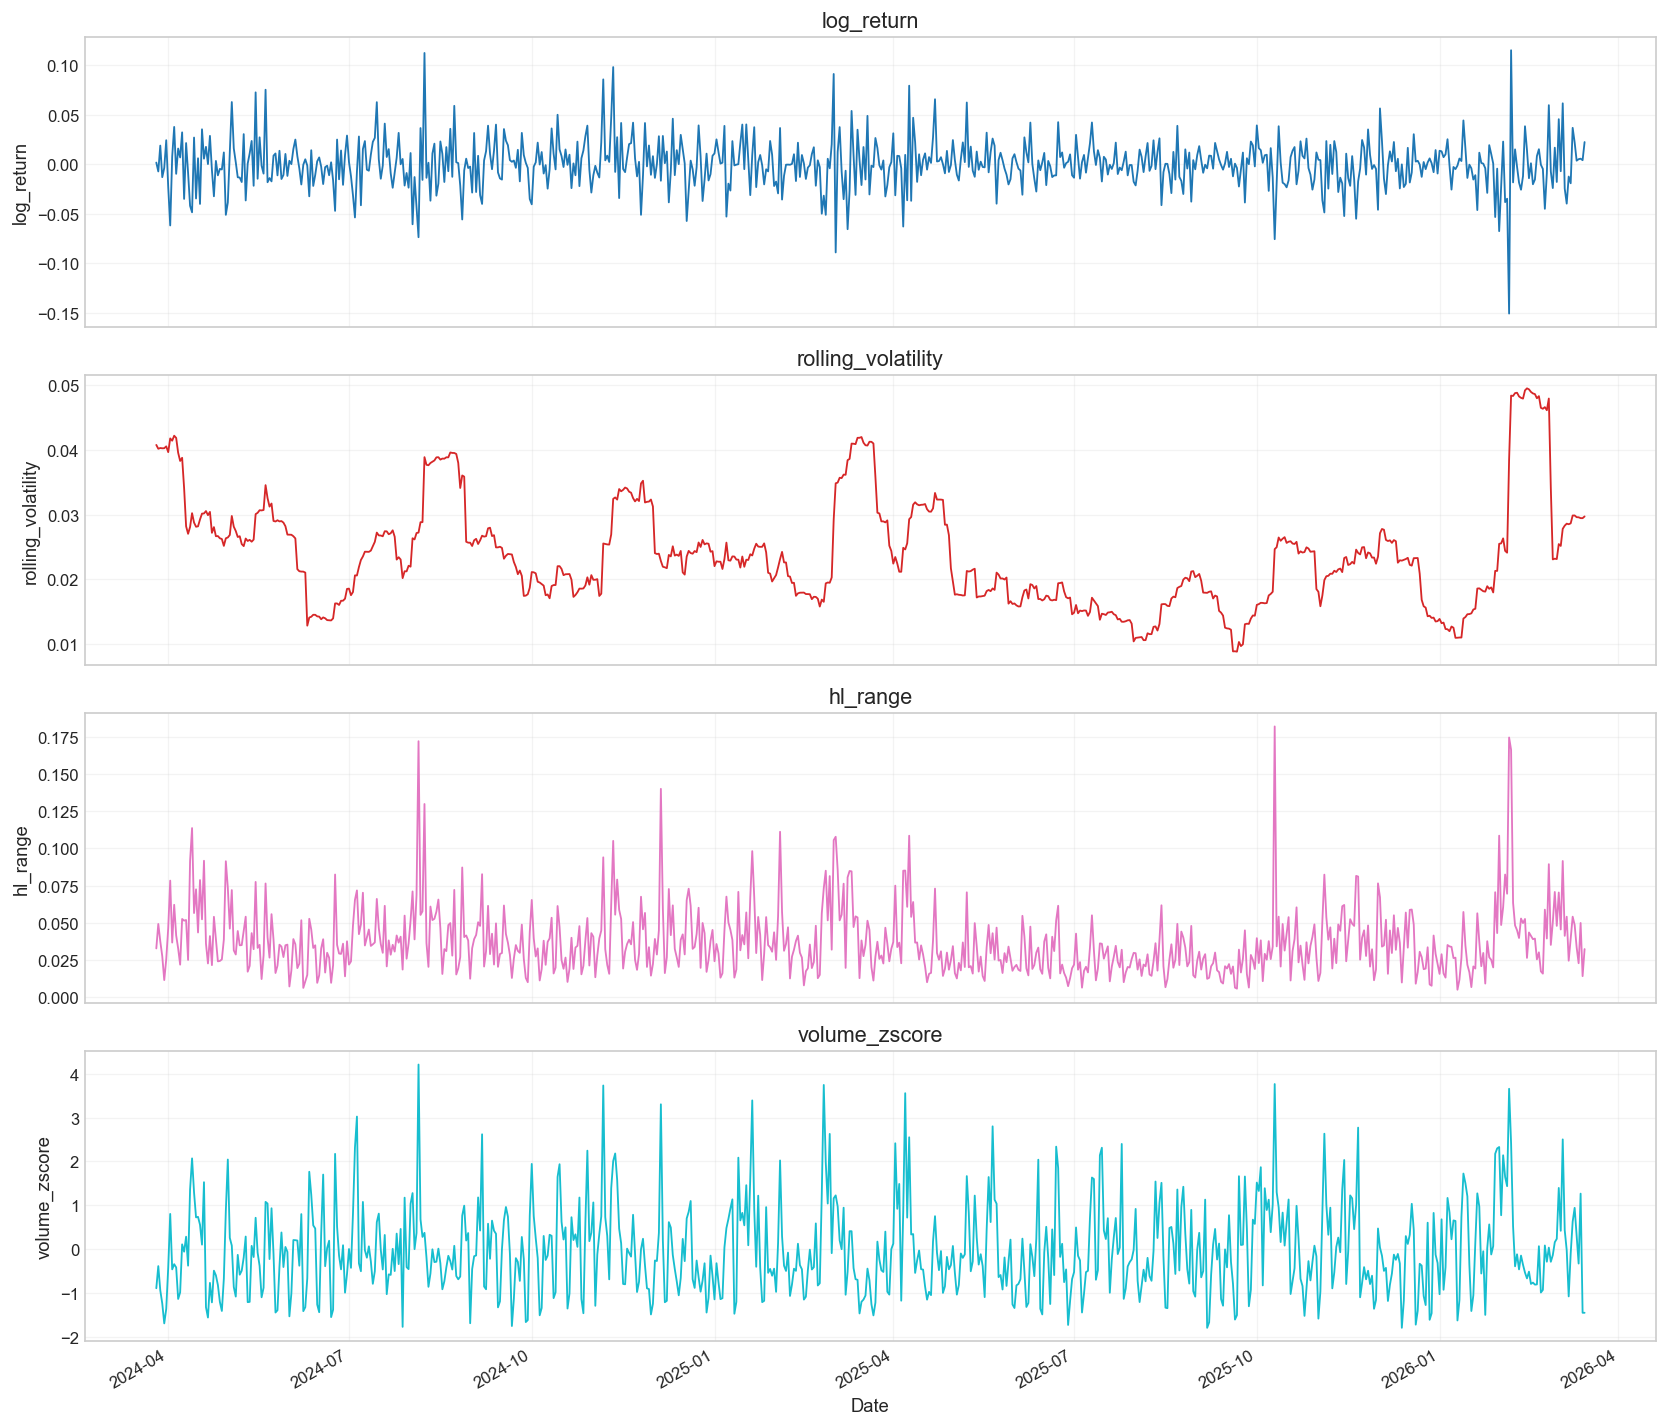

In [5]:
plot_multichannel_overview(
    analysis_feature_frame,
    channels=SELECTED_CHANNELS,
)

## Compute the multivariate matrix profile

`stumpy.mstump` returns one profile row per dimensionality. If the panel contains `d` selected channels, the final row corresponds to the **full-dimensional** profile. That is the row used here for ranking because it preserves the intended multivariate interpretation: motifs must recur in the full selected channel set, not just in a subset.

In [6]:
panel_frame, multivariate_matrix = prepare_multivariate_panel(
    analysis_feature_frame,
    channels=SELECTED_CHANNELS,
)
if len(panel_frame) <= WINDOW_DAYS:
    raise ValueError(
        f"Need more than WINDOW_DAYS={WINDOW_DAYS} clean daily rows for multivariate motif discovery. "
        f"Received {len(panel_frame)} rows."
    )

profile_matrix, index_matrix = stumpy.mstump(multivariate_matrix, m=WINDOW_DAYS)
full_dimensional_row = multivariate_matrix.shape[0] - 1
full_profile = np.asarray(profile_matrix[full_dimensional_row], dtype=np.float64)
full_indices = np.asarray(index_matrix[full_dimensional_row], dtype=np.int64)

motif_df = extract_top_non_overlapping_motifs(
    full_profile,
    full_indices,
    panel_frame["timestamp"],
    window_size=WINDOW_DAYS,
    top_k=TOP_K_MOTIFS,
)
motif_summary = summarize_motifs(motif_df)

if motif_df.empty:
    raise ValueError("No non-overlapping multivariate daily motifs were found for the configured channel set.")

print(f"Rows entering MSTUMP: {len(panel_frame):,}")
print(f"Input matrix shape (channels, rows): {multivariate_matrix.shape}")
print(f"Full-dimensional MSTUMP row used for ranking: {full_dimensional_row}")
print(f"Selected motifs: {len(motif_df)}")

display(motif_summary)

Rows entering MSTUMP: 720
Input matrix shape (channels, rows): (4, 720)
Full-dimensional MSTUMP row used for ranking: 3
Selected motifs: 3


,rank,motif_start,motif_end,nearest_neighbor_start,nearest_neighbor_end,profile_value,window_size
0,1,2025-02-17 00:00:00+00:00,2025-03-18 00:00:00+00:00,2026-01-22 00:00:00+00:00,2026-02-20 00:00:00+00:00,3.865954,30
1,2,2025-10-10 00:00:00+00:00,2025-11-08 00:00:00+00:00,2024-09-06 00:00:00+00:00,2024-10-05 00:00:00+00:00,4.143620,30
2,3,2025-12-01 00:00:00+00:00,2025-12-30 00:00:00+00:00,2025-08-25 00:00:00+00:00,2025-09-23 00:00:00+00:00,4.235474,30


(<Figure size 1680x528 with 1 Axes>,
 <Axes: title={'center': 'BTCUSDT daily multivariate matrix profile'}, xlabel='Subsequence start date', ylabel='Profile value'>)

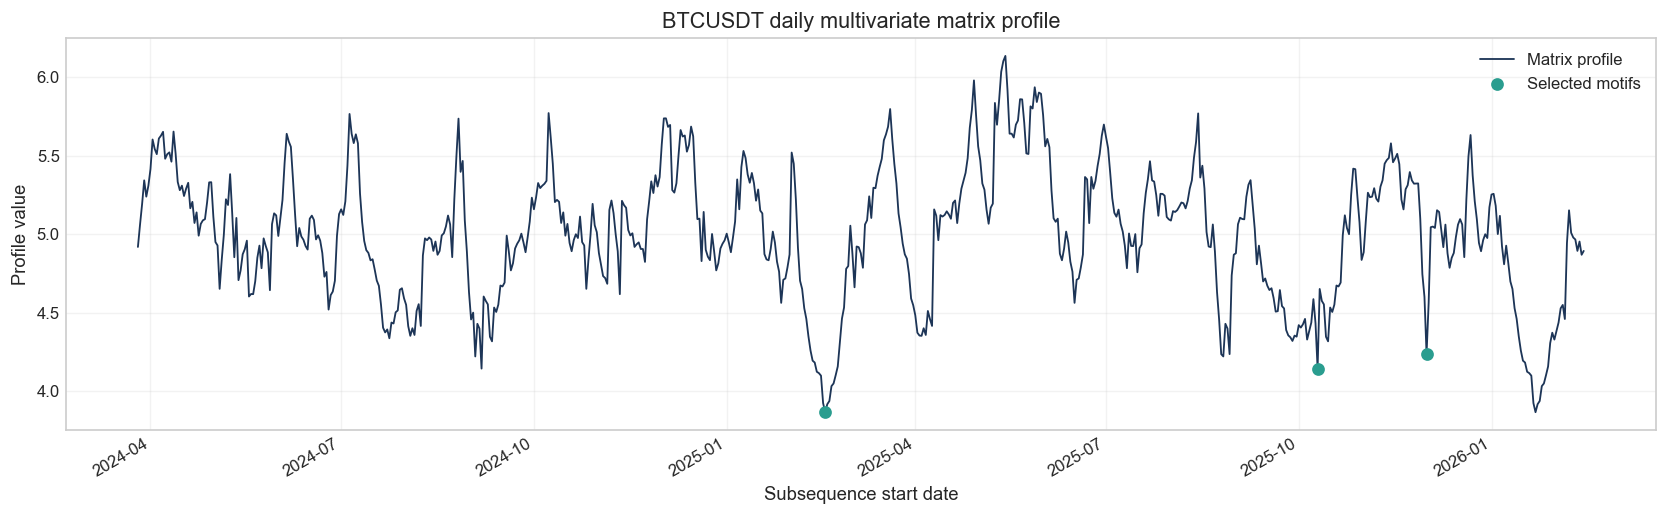

In [7]:
plot_matrix_profile_with_motifs(
    full_profile,
    panel_frame["timestamp"],
    motif_df=motif_df,
    title=f"{source_info['symbol']} daily multivariate matrix profile",
)

(<Figure size 1680x1440 with 4 Axes>,
 array([<Axes: title={'center': 'log_return'}, ylabel='log_return'>,
        <Axes: title={'center': 'rolling_volatility'}, ylabel='rolling_volatility'>,
        <Axes: title={'center': 'hl_range'}, ylabel='hl_range'>,
        <Axes: title={'center': 'volume_zscore'}, xlabel='Date', ylabel='volume_zscore'>],
       dtype=object))

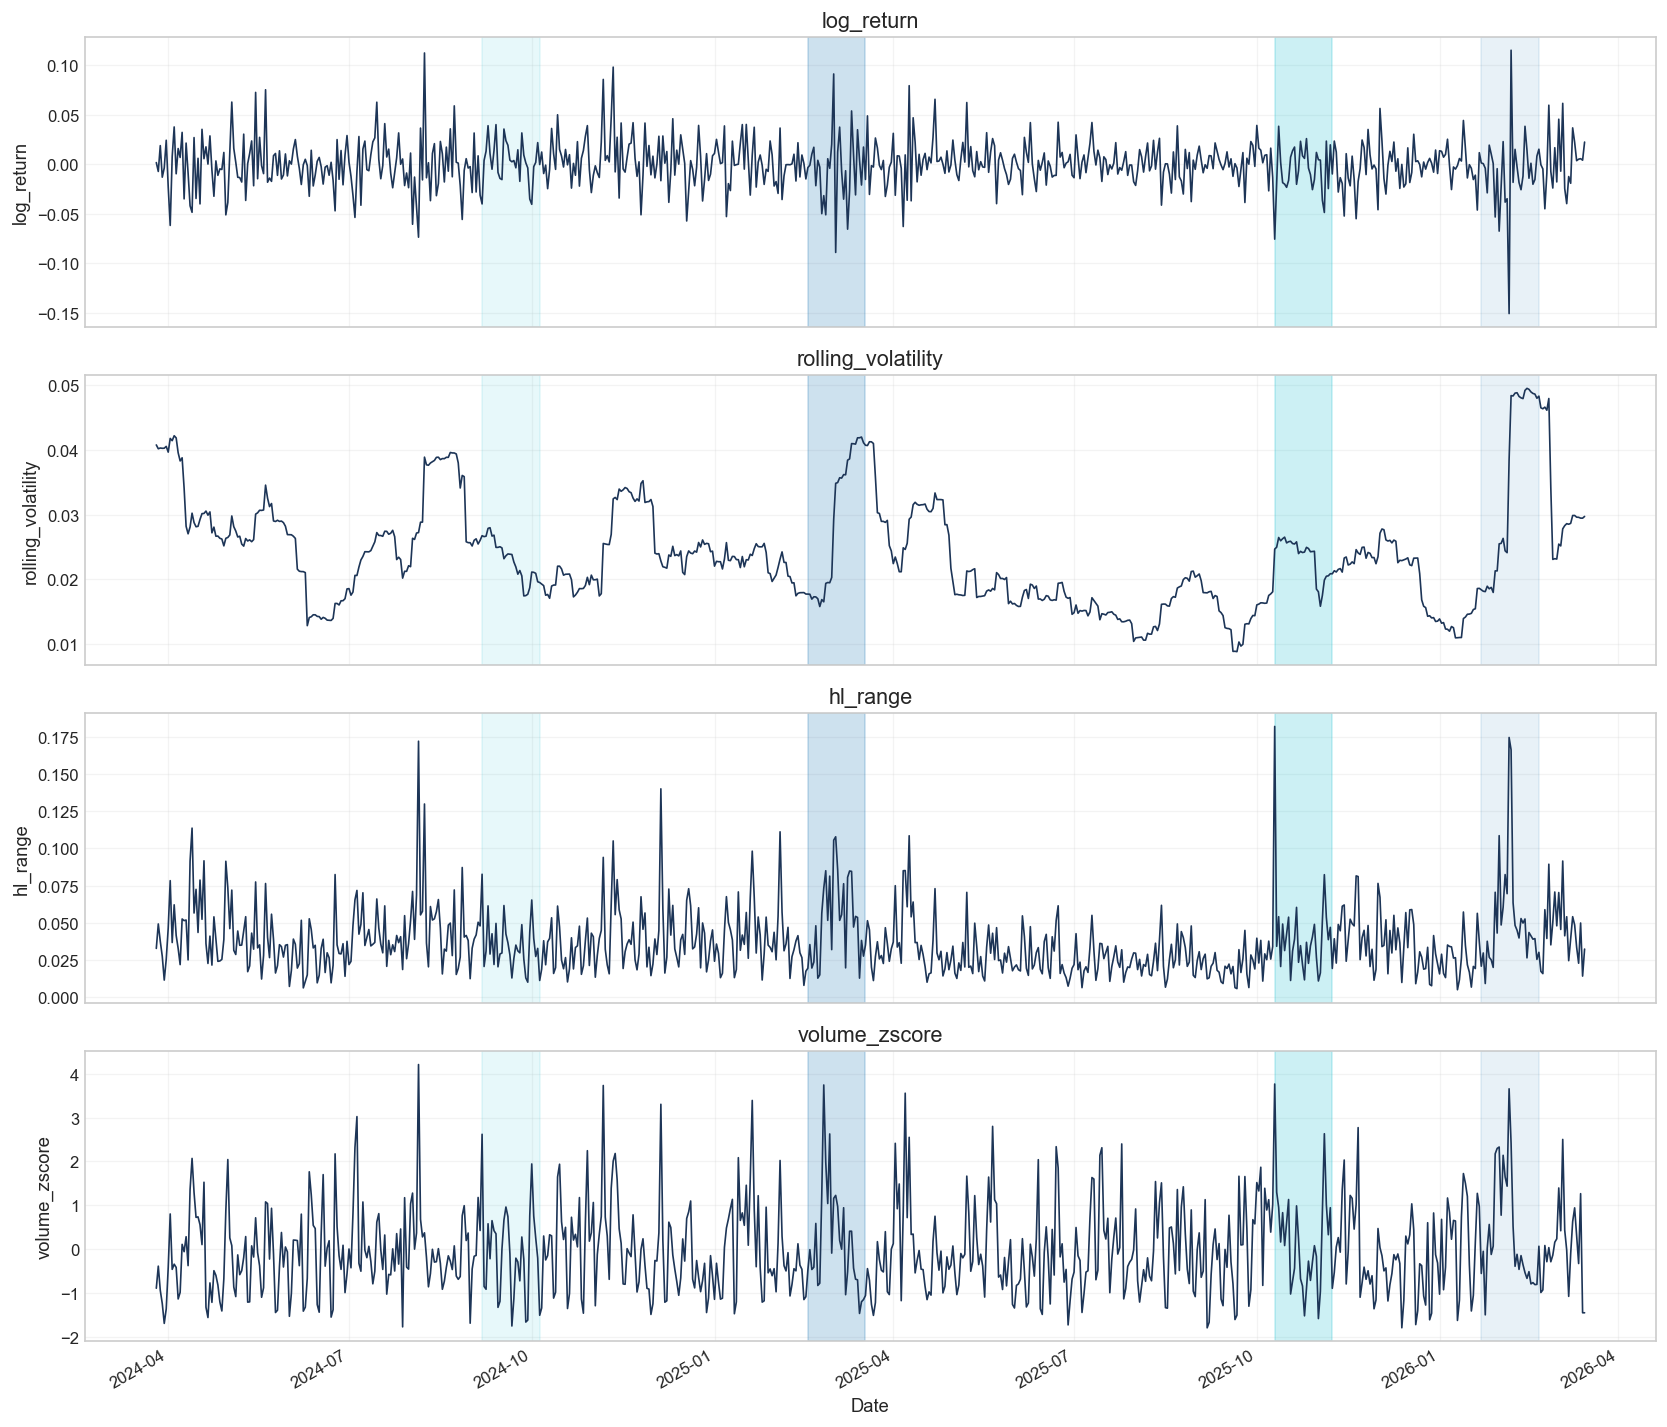

In [8]:
plot_multichannel_windows(
    panel_frame,
    channels=SELECTED_CHANNELS,
    motif_df=motif_df,
    max_motifs=PAIR_PLOTS_TO_RENDER,
)

## Multichannel motif-pair inspection

Each top-ranked motif is inspected twice:

- original-scale side-by-side panels, to preserve the observed daily values and dates in each channel;
- normalized overlays, to isolate shape similarity within each channel.

Motif rank 1 | profile=3.8660 | 2025-02-17 -> 2025-03-18
Motif rank 2 | profile=4.1436 | 2025-10-10 -> 2025-11-08


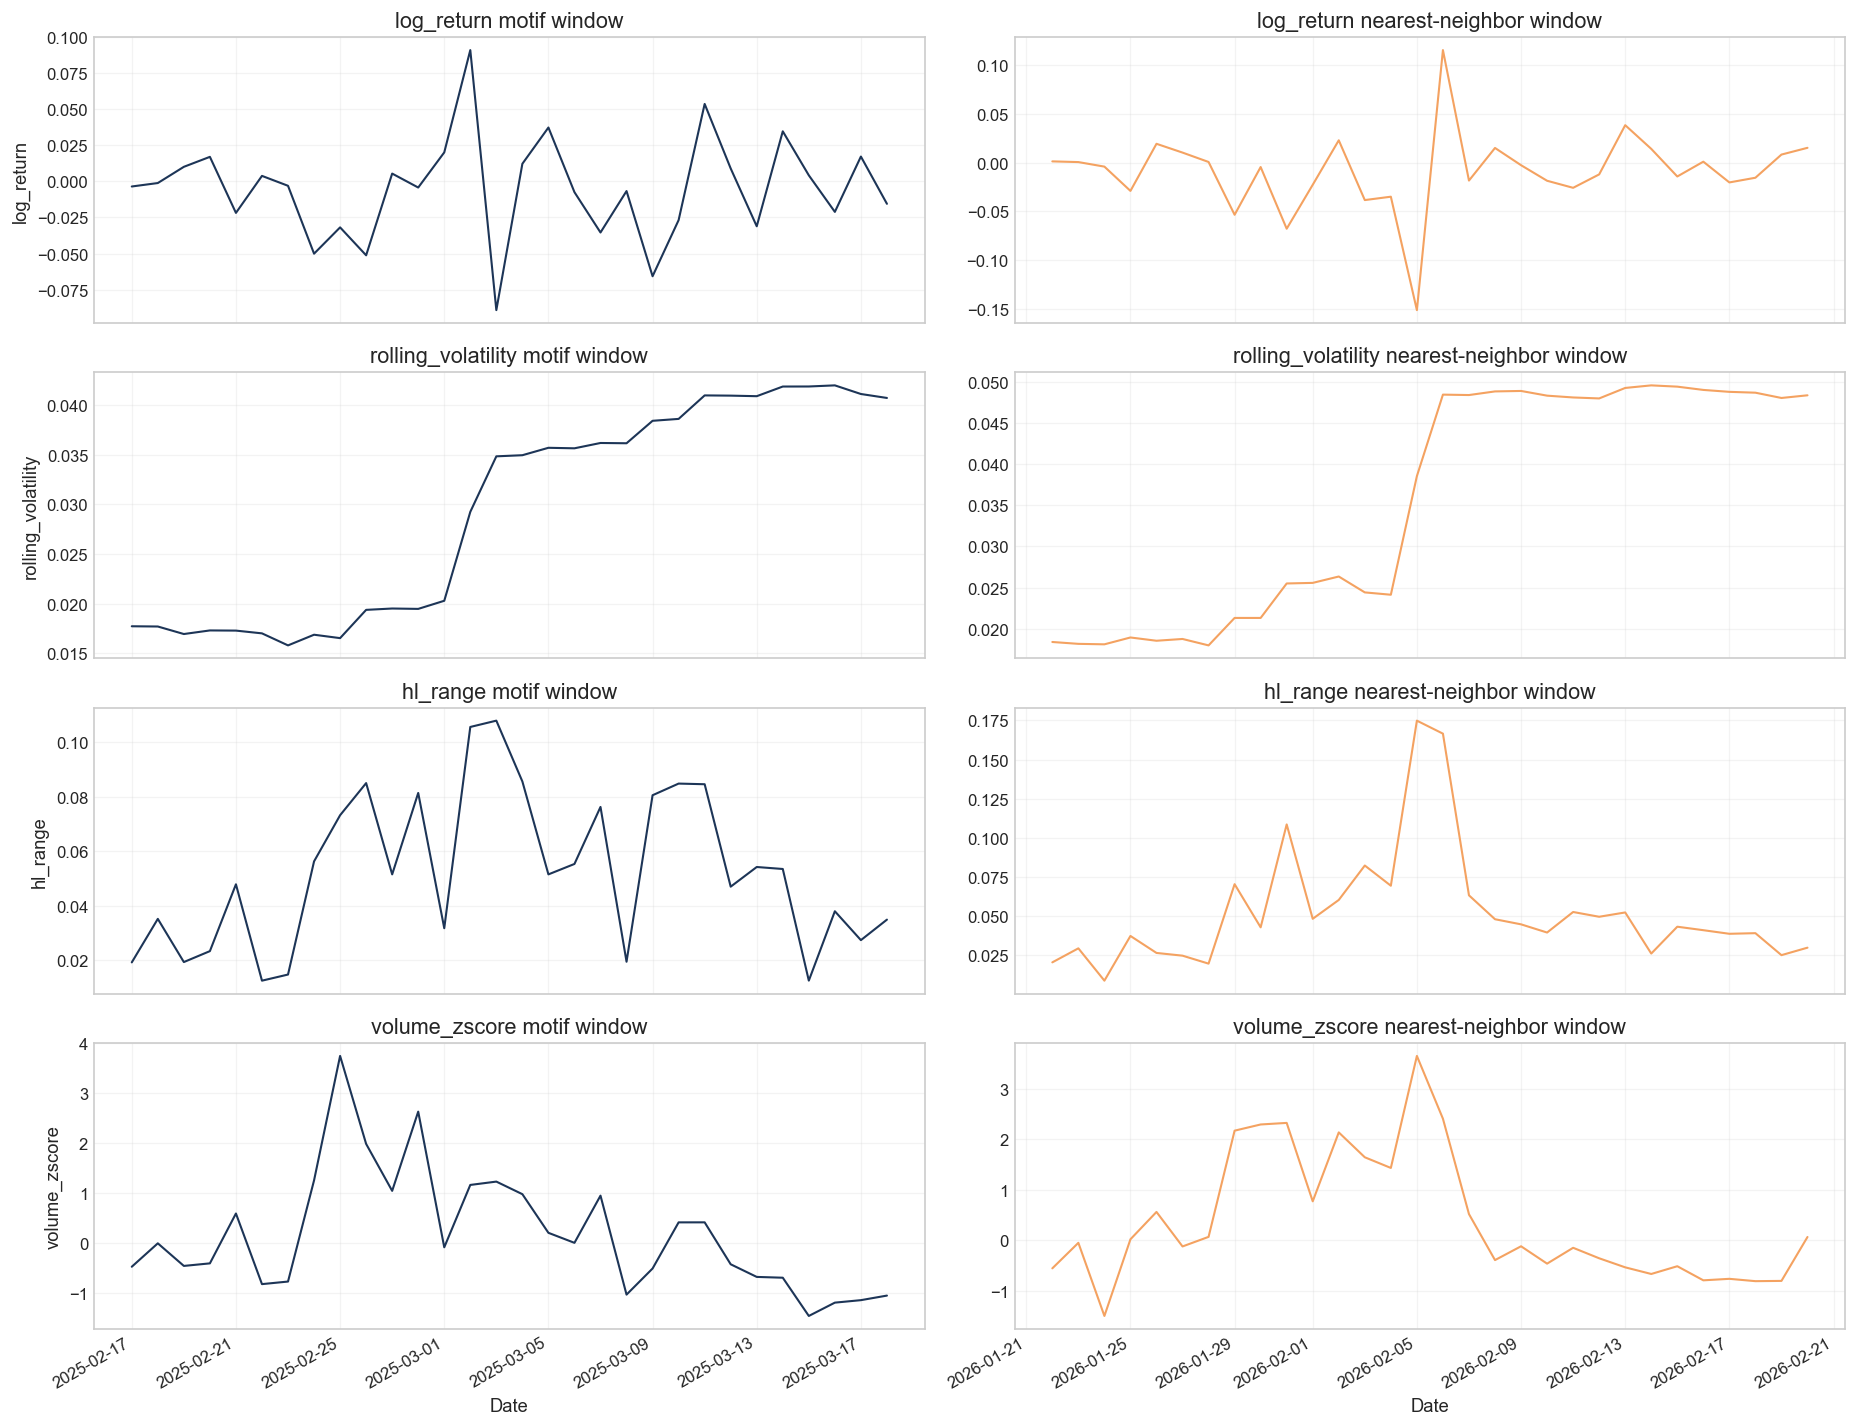

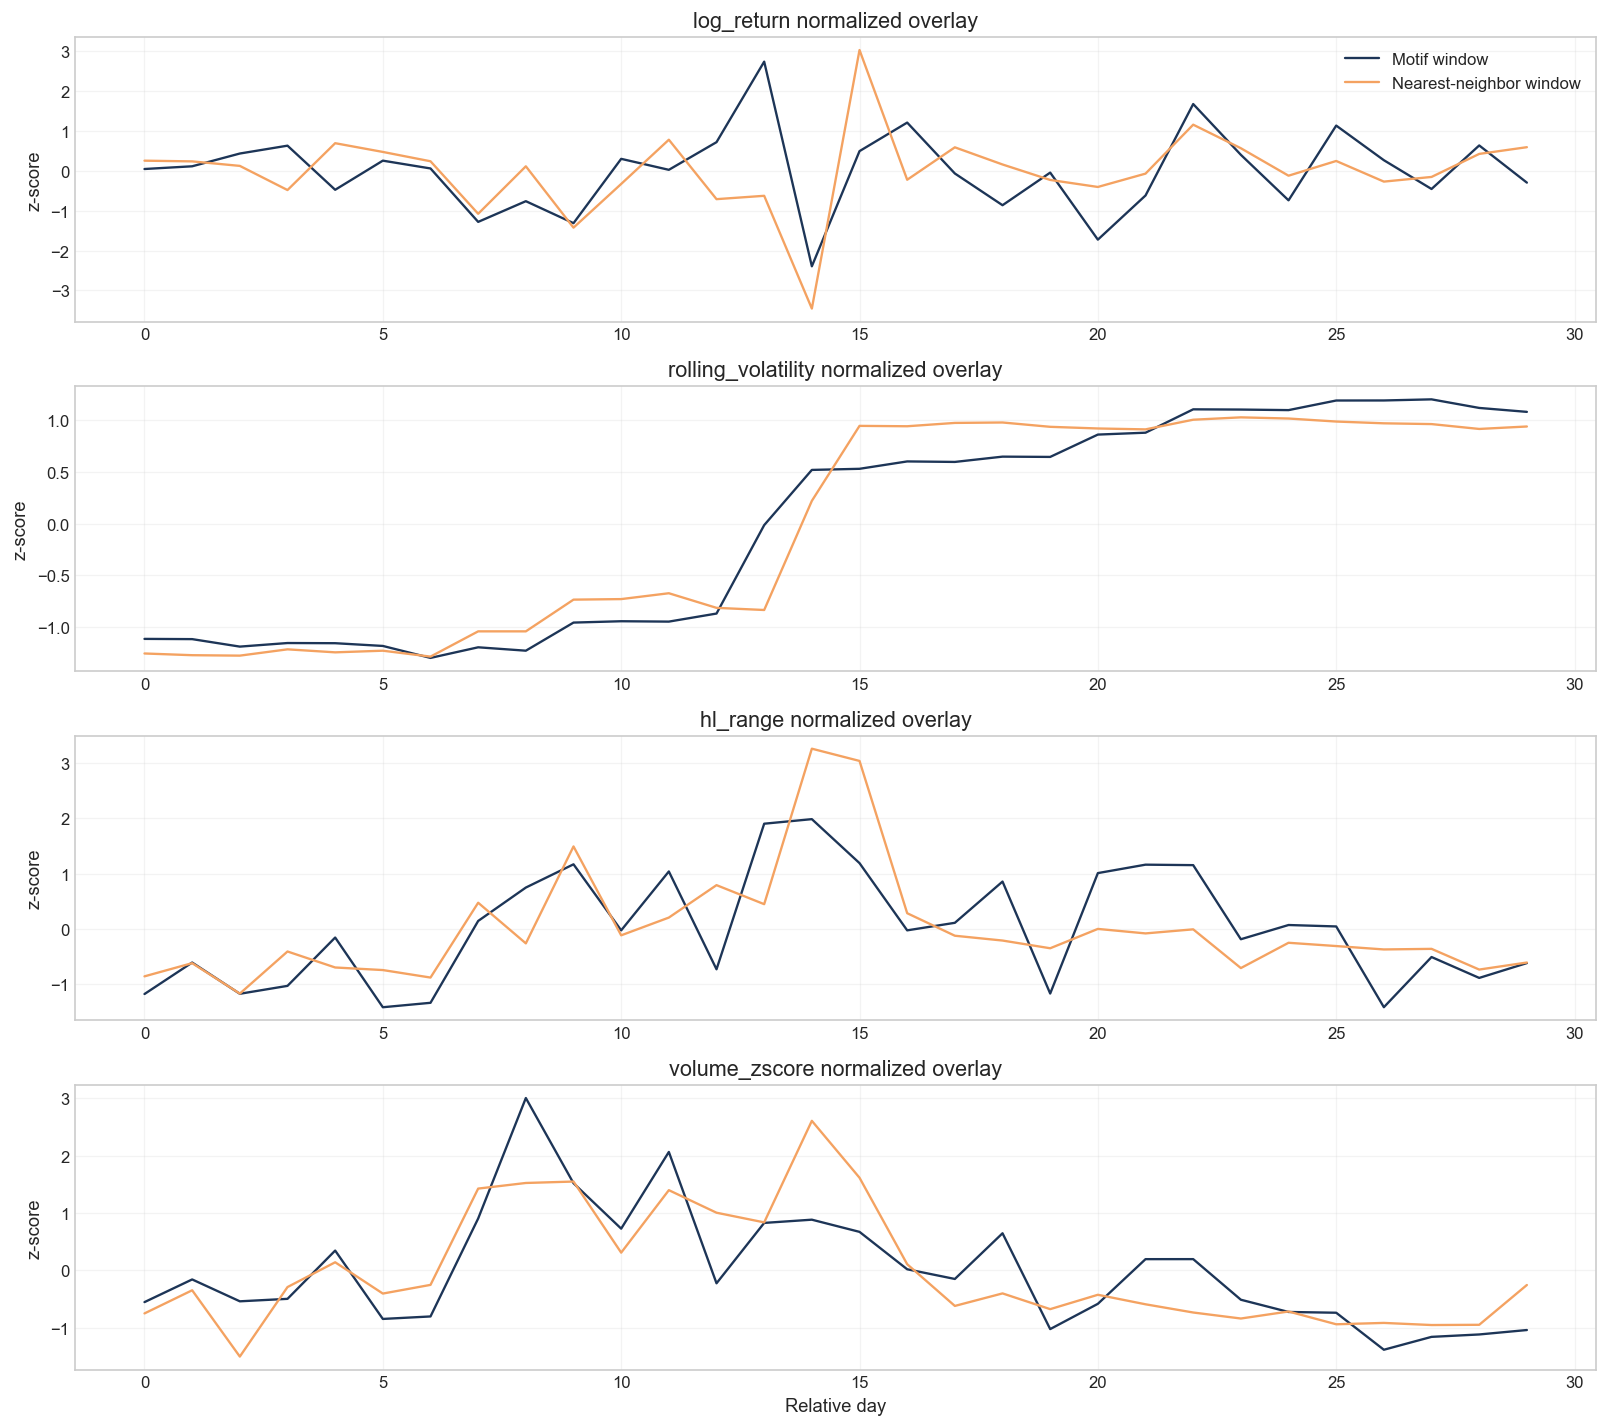

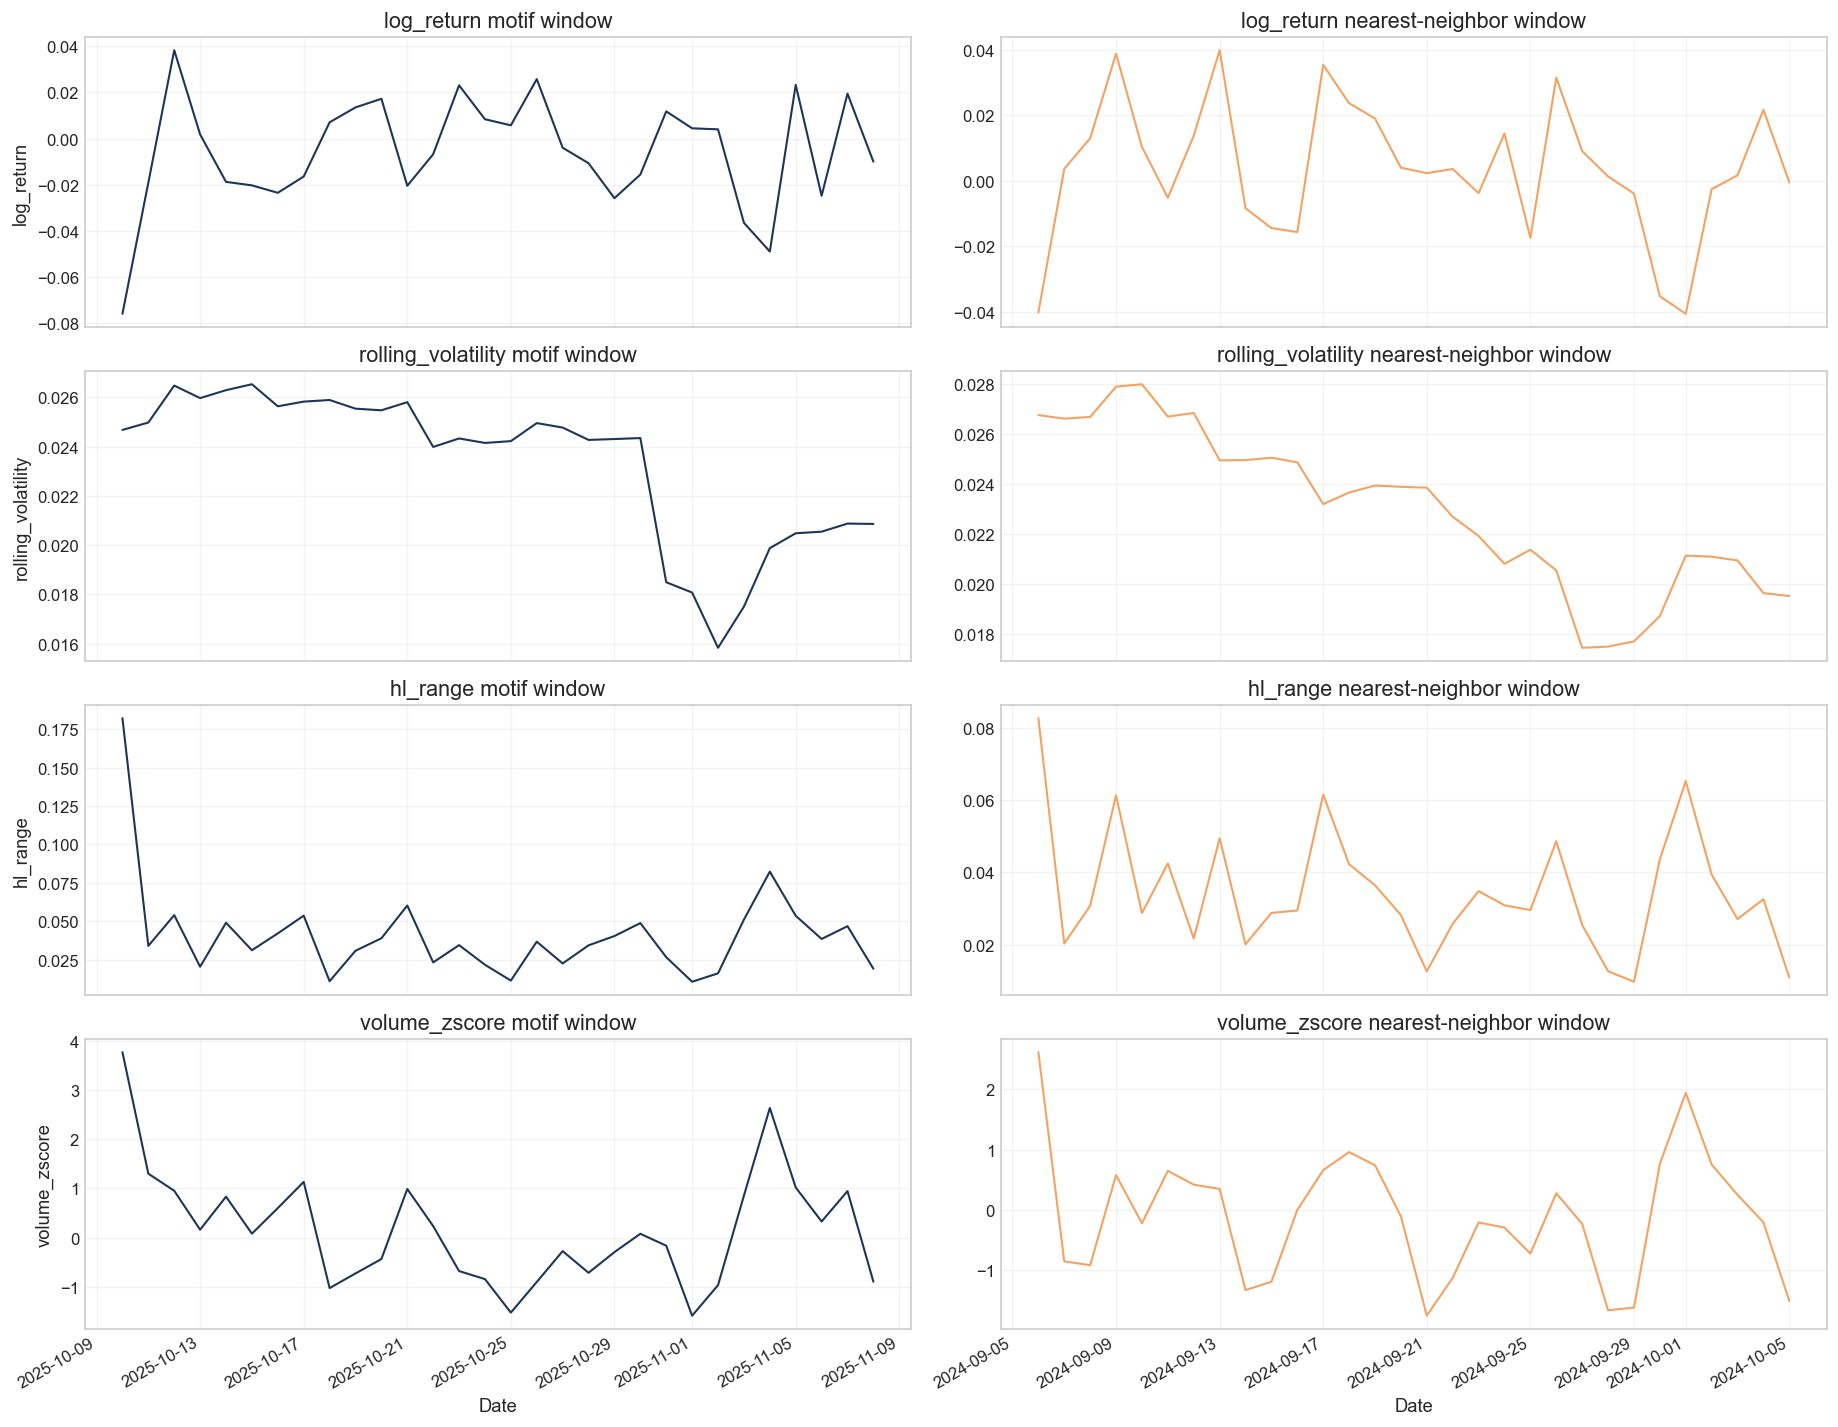

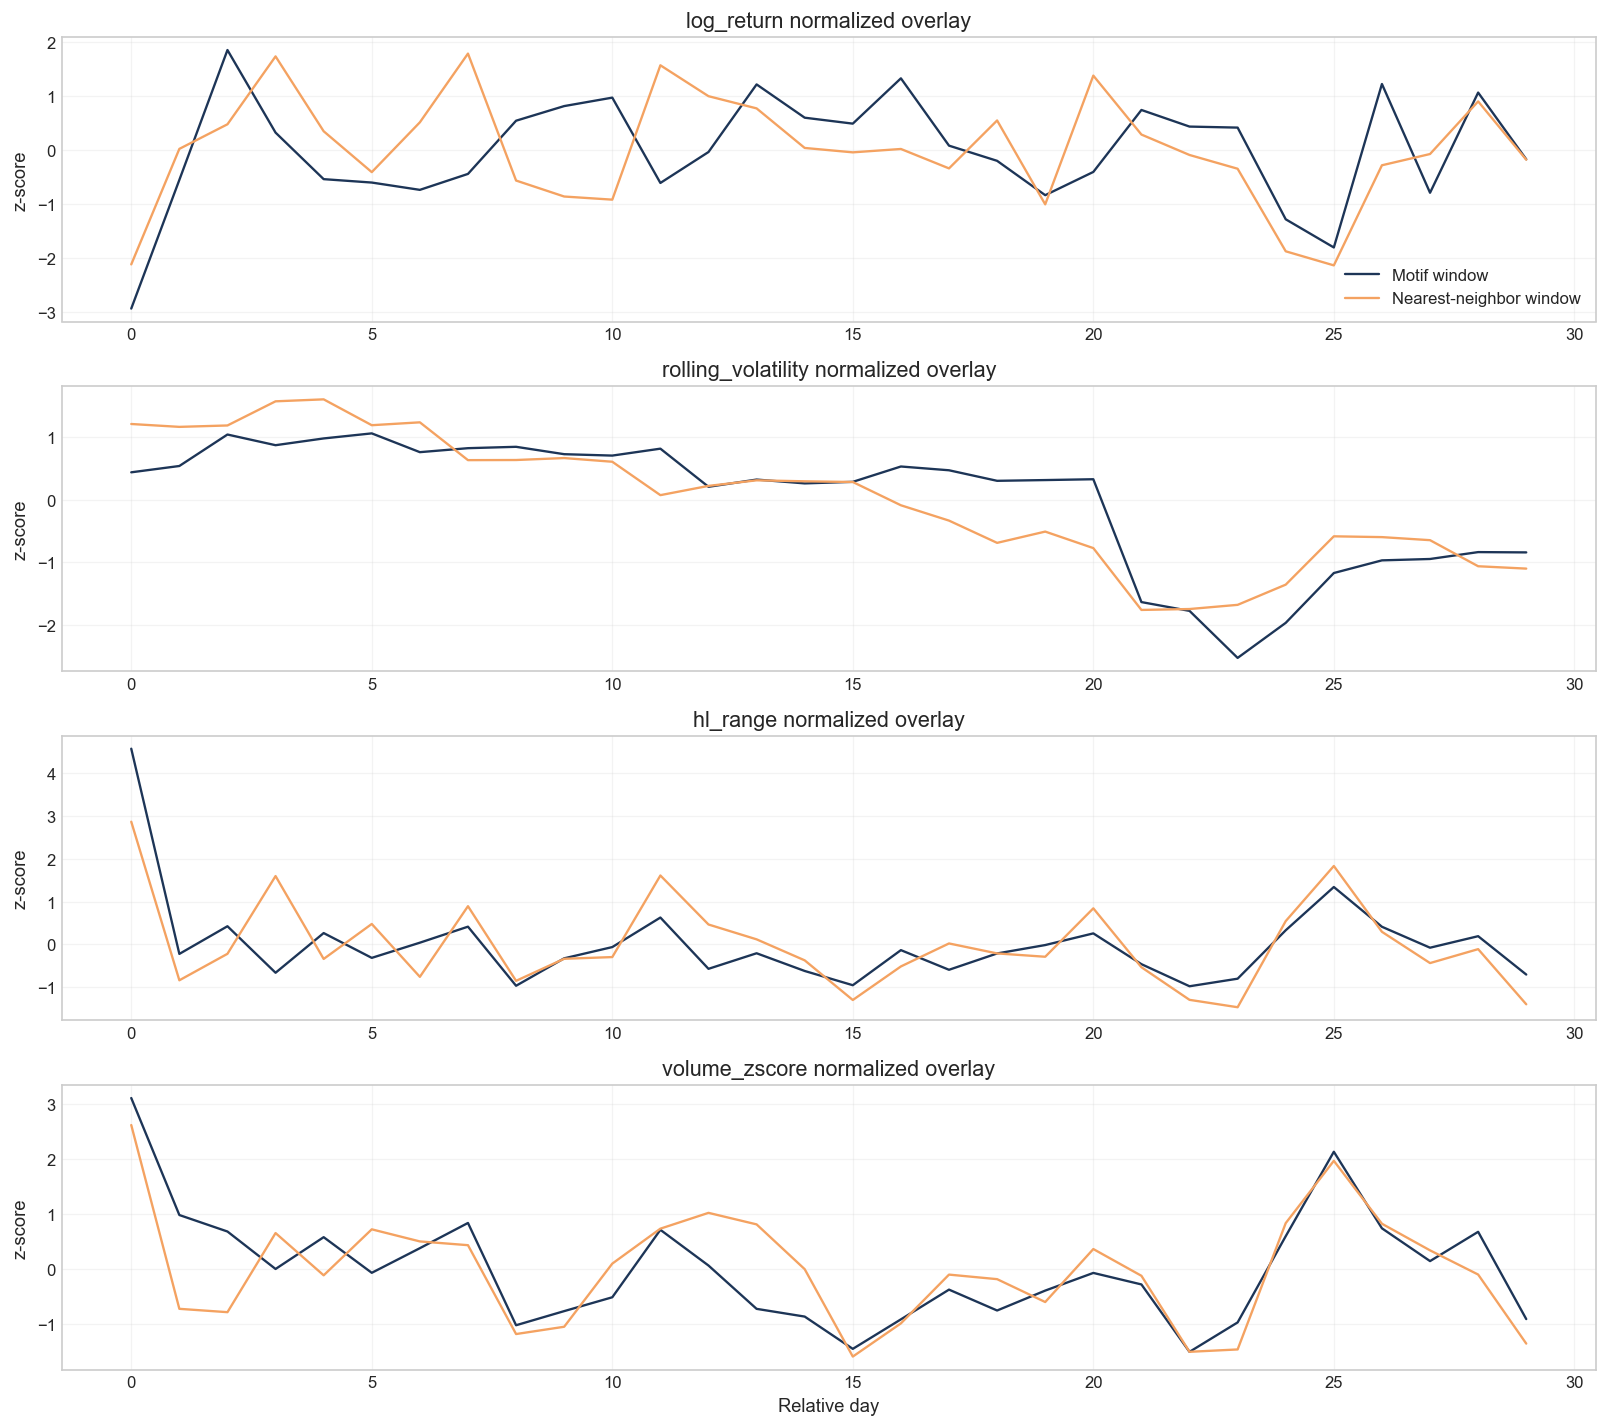

In [9]:
for _, motif_row in motif_df.head(PAIR_PLOTS_TO_RENDER).iterrows():
    print(
        f"Motif rank {int(motif_row['rank'])} | "
        f"profile={motif_row['profile_value']:.4f} | "
        f"{motif_row['motif_start'].date()} -> {motif_row['motif_end'].date()}"
    )
    plot_multichannel_motif_comparison(
        panel_frame,
        channels=SELECTED_CHANNELS,
        motif_row=motif_row,
        window_size=WINDOW_DAYS,
        normalized=False,
    )
    plot_multichannel_motif_comparison(
        panel_frame,
        channels=SELECTED_CHANNELS,
        motif_row=motif_row,
        window_size=WINDOW_DAYS,
        normalized=True,
    )

## Interpretation for the thesis

A strong full-dimensional daily motif suggests that the selected return, volatility, range, and volume channels jointly revisited a similar configuration over the configured horizon. In a daily financial setting, that is closer to a repeated market state than a repeated scalar signal. This makes the notebook a clean bridge toward future regime-conditioned daily analysis, where motif discovery can be stratified or interpreted relative to inferred market regimes without changing the daily data-construction layer.

In [10]:
motif_summary

,rank,motif_start,motif_end,nearest_neighbor_start,nearest_neighbor_end,profile_value,window_size
0,1,2025-02-17 00:00:00+00:00,2025-03-18 00:00:00+00:00,2026-01-22 00:00:00+00:00,2026-02-20 00:00:00+00:00,3.865954,30
1,2,2025-10-10 00:00:00+00:00,2025-11-08 00:00:00+00:00,2024-09-06 00:00:00+00:00,2024-10-05 00:00:00+00:00,4.143620,30
2,3,2025-12-01 00:00:00+00:00,2025-12-30 00:00:00+00:00,2025-08-25 00:00:00+00:00,2025-09-23 00:00:00+00:00,4.235474,30
